In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path
from typing import Tuple, List, Set
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add project root to sys.path
PROJECT_ROOT = Path('../..').resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader.aep.AEPTorchDataset import AEPTorchDataset
from src.models.aep.TransformerModel import TransformerModel


device = torch.device("cuda" if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7 else "cpu")
print(f"\nUsing device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)


Using device: cuda


In [2]:

DEFAULT_DATA_DIR = str(PROJECT_ROOT / "data" / "processed" / "AEP" / "dataset")
DEFAULT_FILENAME = "energydata_complete.csv"
DEFAULT_OUTPUT_ROOT = str(PROJECT_ROOT / "outputs" / "AEP")

In [3]:

MODEL_NAME = "transformer"

OUTPUT_ROOT = Path(DEFAULT_OUTPUT_ROOT)
RUN_DIR = OUTPUT_ROOT / MODEL_NAME


print(f"Model:     {MODEL_NAME}")
print(f"Run dir:   {RUN_DIR}")
print(f"Data dir:  {DEFAULT_DATA_DIR}")

Model:     transformer
Run dir:   /workspace/nirban/projects/counterfactual_basis_kernel/outputs/AEP/transformer
Data dir:  /workspace/nirban/projects/counterfactual_basis_kernel/data/processed/AEP/dataset


In [4]:
# load saved model

# 1. Load preprocess config
with open(RUN_DIR / "preprocess.json", "r") as f:
    preprocess = json.load(f)

print(f"Preprocess config: {json.dumps(preprocess, indent=2)}")

# 2. Load dataset
ds = AEPTorchDataset(data_dir=DEFAULT_DATA_DIR)
train_loader, val_loader, test_loader = ds.load(DEFAULT_FILENAME)

# --- Recompute test-split normalization params for the target column ---
# Re-read and replicate the preprocessing to get test-split min/max
raw_data = pd.read_csv(os.path.join(DEFAULT_DATA_DIR, DEFAULT_FILENAME))
raw_data.drop(['rv1', 'rv2'], axis=1, inplace=True)
raw_data['date'] = pd.to_datetime(raw_data['date'])

# Reproduce the train/val/test split
from sklearn.model_selection import train_test_split as tvt_split
train_raw, test_raw = tvt_split(raw_data, test_size=0.20, shuffle=False)
train_raw, val_raw = tvt_split(train_raw, test_size=0.10, shuffle=False)

# Test-split target stats (matches how AEPTorchDataset normalizes test independently)
target_col_values = test_raw['Appliances'].values.astype(float)
p1 = target_col_values.min()
p2 = target_col_values.max() - target_col_values.min()

# Grab context/date-time info for the test set
U_test = ds.U_test

print(f"Target inverse-transform params: min={p1:.2f}, range={p2:.2f}")
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

# 3. Load model architecture + weights
input_size = preprocess["n_features"]

with open(RUN_DIR / "model_spec.json", "r") as f:
    model_spec = json.load(f)

model_kwargs = model_spec.get("model_kwargs", {})
trained_model = TransformerModel(input_size=input_size, **model_kwargs).to(device)

# Load the best checkpoint
checkpoint_path = RUN_DIR / f"{MODEL_NAME}_best.pt"
if not checkpoint_path.exists():
    candidates = list(RUN_DIR.glob("*.pt")) + list(RUN_DIR.glob("*.pth"))
    if candidates:
        checkpoint_path = candidates[0]
        print(f"Using checkpoint: {checkpoint_path.name}")
    else:
        raise FileNotFoundError(f"No checkpoint found in {RUN_DIR}")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    trained_model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded model from epoch {checkpoint.get('epoch', '?')}")
    if "metrics" in checkpoint:
        print(f"Checkpoint val metrics: {checkpoint['metrics']}")
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    trained_model.load_state_dict(checkpoint["state_dict"])
else:
    trained_model.load_state_dict(checkpoint)

trained_model.eval()
print(f"\n✅ Model loaded successfully from: {checkpoint_path}")
print(f"   Parameters: {sum(p.numel() for p in trained_model.parameters()):,}")

Preprocess config: {
  "dataset_name": "aep",
  "data_dir": "/workspace/nirban/projects/counterfactual_basis_kernel/data/processed/AEP/dataset",
  "filename": "energydata_complete.csv",
  "feature_cols": [
    "nsm",
    "lights",
    "T1",
    "T2",
    "T3",
    "T4",
    "RH_4",
    "T5",
    "T6",
    "T7",
    "RH_7",
    "T8",
    "RH_8",
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint",
    "Appliances"
  ],
  "n_features": 21,
  "seq_len": 12,
  "batch_size": 256,
  "n_past": 12,
  "n_future": 1,
  "normalisation": "minmax",
  "target_col": "Appliances",
  "n_train": 14197,
  "n_val": 1567,
  "n_test": 3935
}
25 14209
25 1579
25 3947
Target inverse-transform params: min=20.00, range=830.00
Train: 14197 | Val: 1567 | Test: 3935
Using checkpoint: transformer_best_best.pth

✅ Model loaded successfully from: /workspace/nirban/projects/counterfactual_basis_kernel/outputs/AEP/transformer/transformer_best_best.pth
   Parameters: 276,097


--- Final Transformer Metrics on Original Scale ---
[RMSE: 59.3906]
[R2 SCORE: 0.5373]
[MAE: 26.1397]


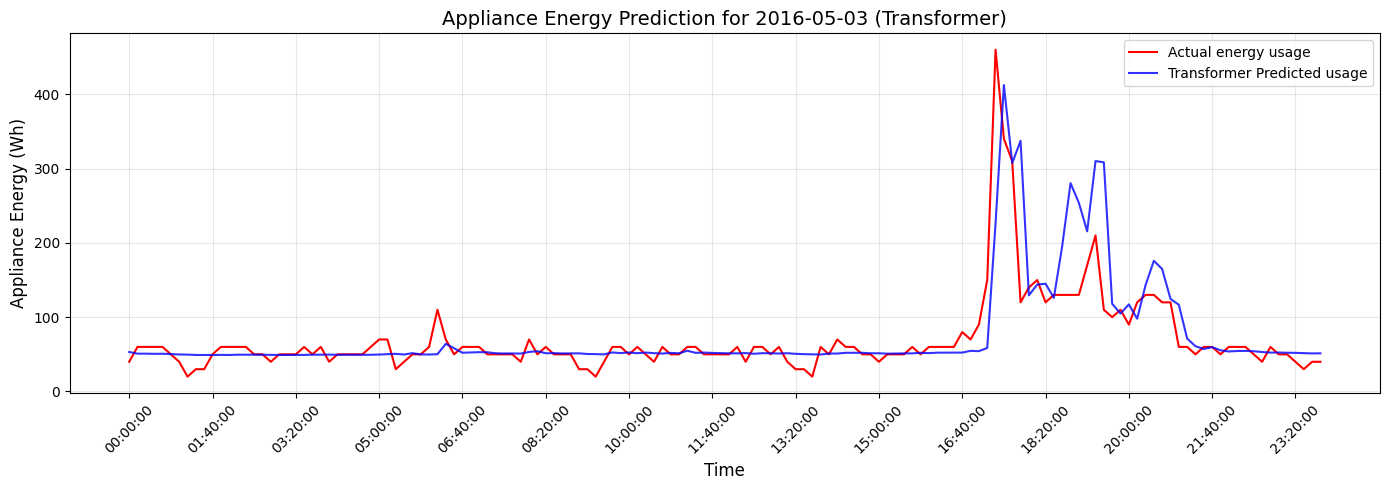

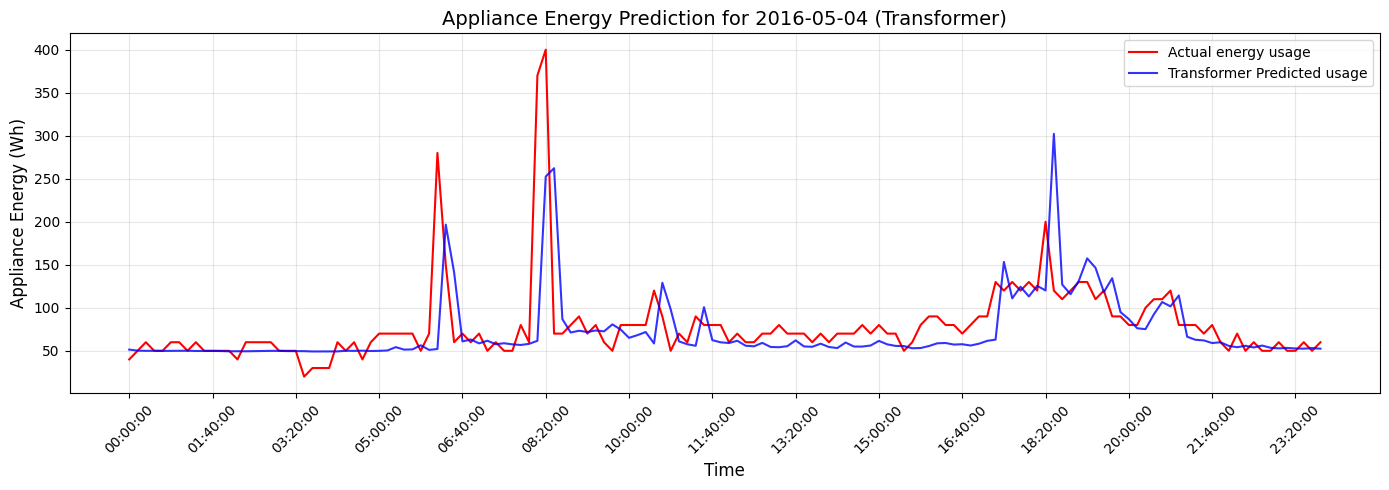

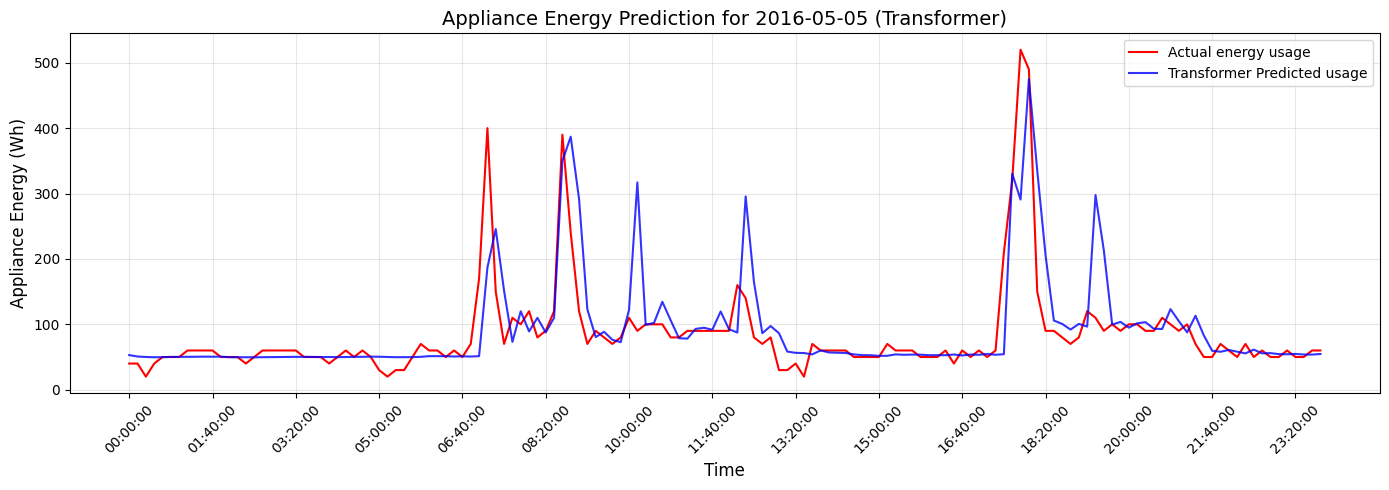

In [5]:

# 1. Define Helper Functions
def calculate_metrics(actual, predicted):
    return {'mae': mean_absolute_error(actual, predicted),
            'rmse': mean_squared_error(actual, predicted) ** 0.5,
            'r2': r2_score(actual, predicted)}

def inv_trans(data, p1, p2):
    return data * p2 + p1

# 2. Evaluate Model on Test Set
trained_model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        pred = trained_model(x_test)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_test.numpy())

# 3. Flatten Tensors and Reshape
vals = np.concatenate(actuals, axis=0).ravel()
preds = np.concatenate(predictions, axis=0).ravel()

target_val_norm = np.reshape(vals, (len(vals), 1))
pred_val_norm = np.reshape(preds, (len(preds), 1))

# 4. Apply Inverse Transform (using p1, p2 saved from your normalization cell)
target_val = inv_trans(target_val_norm, p1, p2)
pred_val = inv_trans(pred_val_norm, p1, p2)

# 5. Print Final Un-normalized Metrics
print('--- Final Transformer Metrics on Original Scale ---')
metrics = calculate_metrics(target_val, pred_val)
print(f"[RMSE: {metrics['rmse']:.4f}]")
print(f"[R2 SCORE: {metrics['r2']:.4f}]")
print(f"[MAE: {metrics['mae']:.4f}]")

# 6. Construct clean DataFrame with True Dates & Times
df_results = pd.DataFrame({'target': target_val[:, 0], 'predicted': pred_val[:, 0]})
U_test_clean = U_test.reset_index(drop=True)
df_results = pd.concat([U_test_clean, df_results], axis=1)

df_results['date'] = df_results['date'].astype(str)
df_results['time'] = df_results['time'].astype(str)

# 7. Plotting Function for Multiple Dates
dates_to_plot = ['2016-05-03', '2016-05-04', '2016-05-05']

def plot_multiple_results(df, dates):
    for date_to_plot in dates:
        plot_data = df[df['date'] == date_to_plot].reset_index(drop=True)

        if plot_data.empty:
            print(f"No data found for date: {date_to_plot}")
            continue

        plt.figure(figsize=(14, 5))
        plt.plot(plot_data['target'], label='Actual energy usage', color='red', linewidth=1.5)
        plt.plot(plot_data['predicted'], label='Transformer Predicted usage', color='blue', alpha=0.8, linewidth=1.5)

        plt.title(f'Appliance Energy Prediction for {date_to_plot} (Transformer)', fontsize=14)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Appliance Energy (Wh)', fontsize=12)
        plt.legend()

        # Tick formatting
        ticks = range(0, len(plot_data), 10)
        tick_labels = plot_data['time'].iloc[ticks]

        plt.xticks(ticks, tick_labels, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# 8. Trigger the plotting loop
plot_multiple_results(df_results, dates_to_plot)